<a href="https://colab.research.google.com/github/garvit-07/Sentiment_analysis/blob/main/Sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install -q transformers datasets evaluate accelerate gradio scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.4 MB/s eta 0:00:00


In [2]:
import numpy as np, torch, matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
from datasets import load_dataset
from transformers import (
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback,
)
import evaluate

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

LABEL_NAMES = ['sadness','joy','love','anger','fear','surprise']
LABEL_EMOJI = ['😢','😊','❤️','😠','😨','😮']
NUM_LABELS  = 6
MAX_LENGTH  = 128

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


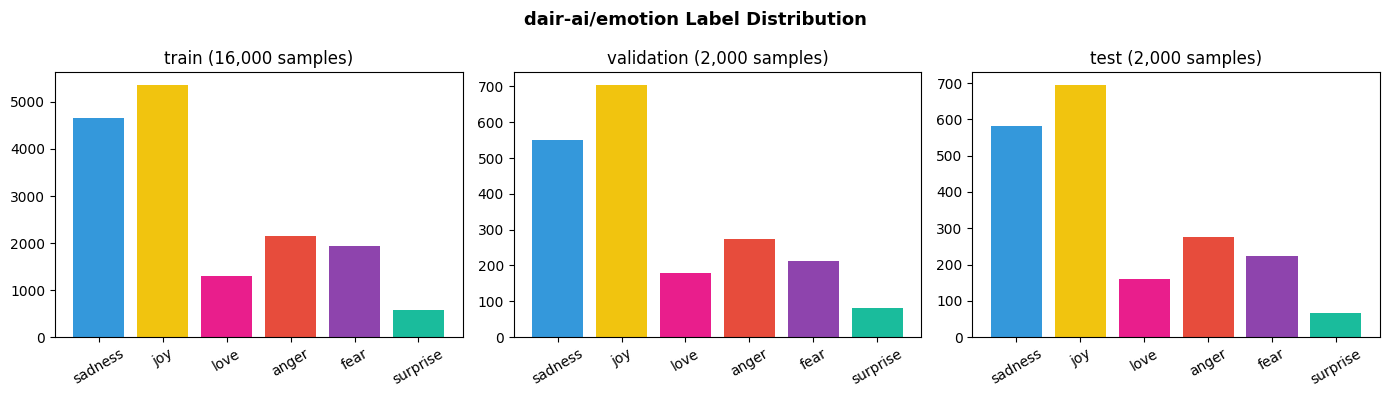


Sample tweet: {'text': 'i didnt feel humiliated', 'label': 0}


In [3]:

ds = load_dataset('dair-ai/emotion')
print(ds)

fig, axes = plt.subplots(1,3, figsize=(14,4))
for ax, split in zip(axes, ['train','validation','test']):
    counts = Counter(ds[split]['label'])
    ax.bar(LABEL_NAMES, [counts[i] for i in range(6)],
           color=['#3498DB','#F1C40F','#E91E8C','#E74C3C','#8E44AD','#1ABC9C'])
    ax.set_title(f'{split} ({len(ds[split]):,} samples)')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('dair-ai/emotion Label Distribution', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('\nSample tweet:', ds['train'][0])

In [4]:

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=MAX_LENGTH)

tokenized = ds.map(tokenize_fn, batched=True, batch_size=512)
tokenized = tokenized.rename_column('label', 'labels')
tokenized.set_format('torch', columns=['input_ids','attention_mask','labels'])
print('Tokenization done ✅')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenization done ✅


In [5]:

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=NUM_LABELS
)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters: 66,958,086


In [6]:

acc_m = evaluate.load('accuracy')
f1_m  = evaluate.load('f1')

def compute_metrics(ep):
    preds = np.argmax(ep.predictions, axis=-1)
    return {
        'accuracy':    acc_m.compute(predictions=preds, references=ep.label_ids)['accuracy'],
        'f1_weighted': f1_m.compute(predictions=preds, references=ep.label_ids, average='weighted')['f1'],
    }

In [7]:

args = TrainingArguments(
    output_dir                  = '/content/emotion_model',
    num_train_epochs            = 4,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.06,
    lr_scheduler_type           = 'cosine',
    eval_strategy         = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_weighted',
    fp16                        = True,   # T4 GPU supports FP16
    report_to                   = 'none',
)

trainer = Trainer(
    model=model, args=args,
    train_dataset=tokenized['train'],
    eval_dataset =tokenized['validation'],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.739975,0.217415,0.921500,0.921843
2,0.171256,0.154512,0.938000,0.937597
3,0.109866,0.139170,0.940500,0.940812
4,0.080954,0.137283,0.941500,0.941378


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2000, training_loss=0.27551272201538085, metrics={'train_runtime': 256.1961, 'train_samples_per_second': 249.809, 'train_steps_per_second': 7.807, 'total_flos': 2119629570048000.0, 'train_loss': 0.27551272201538085, 'epoch': 4.0})

              precision    recall  f1-score   support

     sadness       0.96      0.97      0.96       581
         joy       0.95      0.95      0.95       695
        love       0.80      0.84      0.82       159
       anger       0.92      0.92      0.92       275
        fear       0.89      0.90      0.90       224
    surprise       0.81      0.65      0.72        66

    accuracy                           0.93      2000
   macro avg       0.89      0.87      0.88      2000
weighted avg       0.92      0.93      0.92      2000



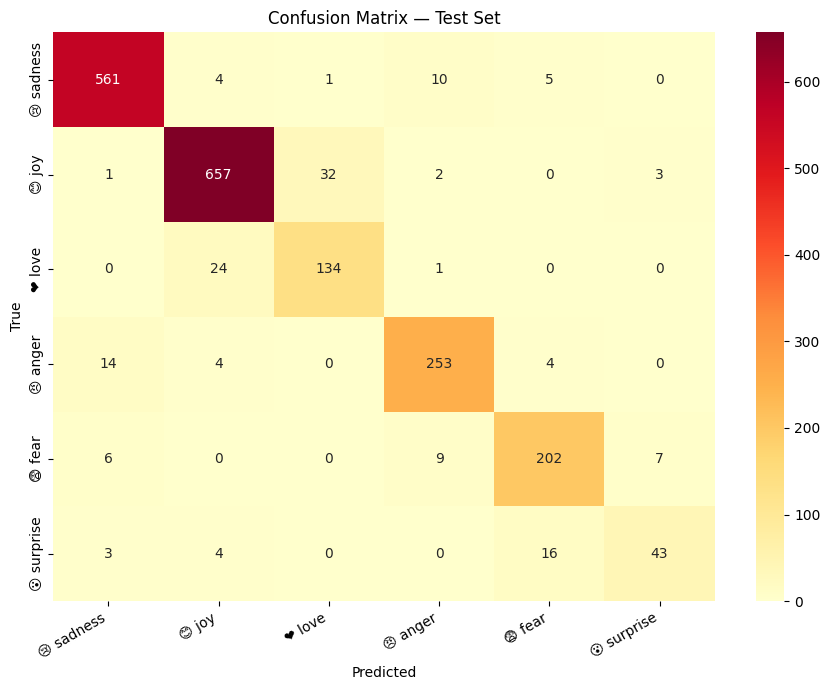

In [8]:

out    = trainer.predict(tokenized['test'])
preds  = np.argmax(out.predictions, axis=-1)
labels = out.label_ids

print(classification_report(labels, preds, target_names=LABEL_NAMES))

cm = confusion_matrix(labels, preds)
label_display = [f'{LABEL_EMOJI[i]} {LABEL_NAMES[i]}' for i in range(6)]
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=label_display, yticklabels=label_display)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

In [10]:
def predict(text):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)
    model.eval()

    inp = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    )


    inp = {k: v.to(device) for k, v in inp.items()}

    with torch.no_grad():
        outputs = model(**inp)
        probs = torch.softmax(outputs.logits, dim=-1).squeeze().cpu().numpy()

    pred = int(np.argmax(probs))

    print(f'\n"{text}"')
    print(f'  → {LABEL_EMOJI[pred]} {LABEL_NAMES[pred].upper()} ({probs[pred]:.1%} confidence)')

predict('I just got promoted at work and I cannot stop smiling!')
predict('I miss her so much, the silence at home is unbearable.')
predict('How dare you speak to me like that, I am absolutely furious.')
predict('She surprised me with a trip to Paris this weekend!')


"I just got promoted at work and I cannot stop smiling!"
  → 😊 JOY (99.3% confidence)

"I miss her so much, the silence at home is unbearable."
  → 😢 SADNESS (99.4% confidence)

"How dare you speak to me like that, I am absolutely furious."
  → 😠 ANGER (99.6% confidence)

"She surprised me with a trip to Paris this weekend!"
  → 😮 SURPRISE (97.6% confidence)
